ACTUAL COLUMNS IN YOUR DATASET:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
--------------------------------------------------

Random Forest R2 Score: 0.9643601062650229
Mean Squared Error: 0.8209857844262285


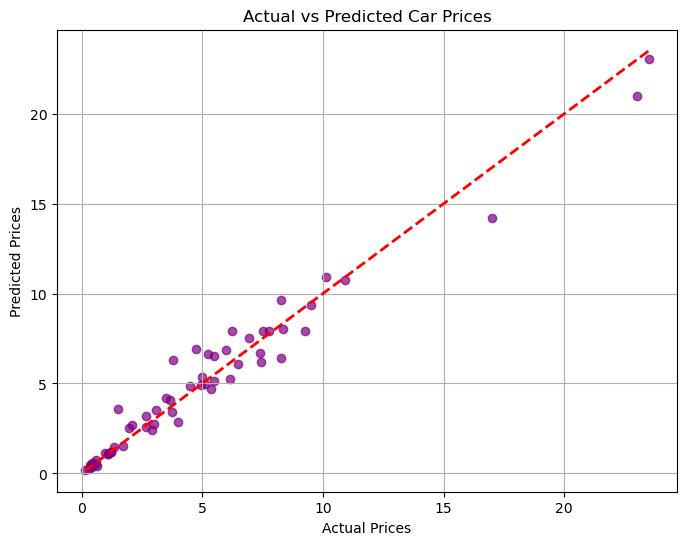

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
FILE_NAME = "car data.csv" # <-- Make sure this is your downloaded file name
df = pd.read_csv(FILE_NAME)
df = df.dropna()

# --- DIAGNOSTIC STEP ---
print("ACTUAL COLUMNS IN YOUR DATASET:")
print(df.columns.tolist())
print("-" * 50)
# -----------------------

# 2. Preprocessing & Feature Engineering
# If you get an error below, look at the columns printed above and update this list!
features = ['Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

# This checks if your features match and stops the code gracefully if they don't
missing_cols = [col for col in features if col not in df.columns]

if missing_cols:
    print(f"\nSTOPPING: The following columns were NOT found in your dataset: {missing_cols}")
    print("Look at the 'ACTUAL COLUMNS' printed above. Find the correct spelling/capitalization for the missing columns and update the 'features' list in the code.")
else:
    X = pd.get_dummies(df[features], drop_first=True)
    
    # Also ensure your target column matches exactly (e.g., 'selling_price' vs 'Selling_Price')
    target_col = 'Selling_Price'
    if target_col not in df.columns:
        print(f"\nSTOPPING: Target column '{target_col}' not found. Please update the 'target_col' variable.")
    else:
        y = df[target_col]
        
        # 3. Train Model
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        # 4. Evaluation
        print("\nRandom Forest R2 Score:", r2_score(y_test, predictions))
        print("Mean Squared Error:", mean_squared_error(y_test, predictions))
        
        # 5. Visualization
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, predictions, alpha=0.7, color="purple")
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel("Actual Prices")
        plt.ylabel("Predicted Prices")
        plt.title("Actual vs Predicted Car Prices")
        plt.grid(True)
        plt.show()